/var/folders/78/9cl0kydx0g3cdzjyk28yzr7w0000gn/T/ipykernel_23389/2708110464.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


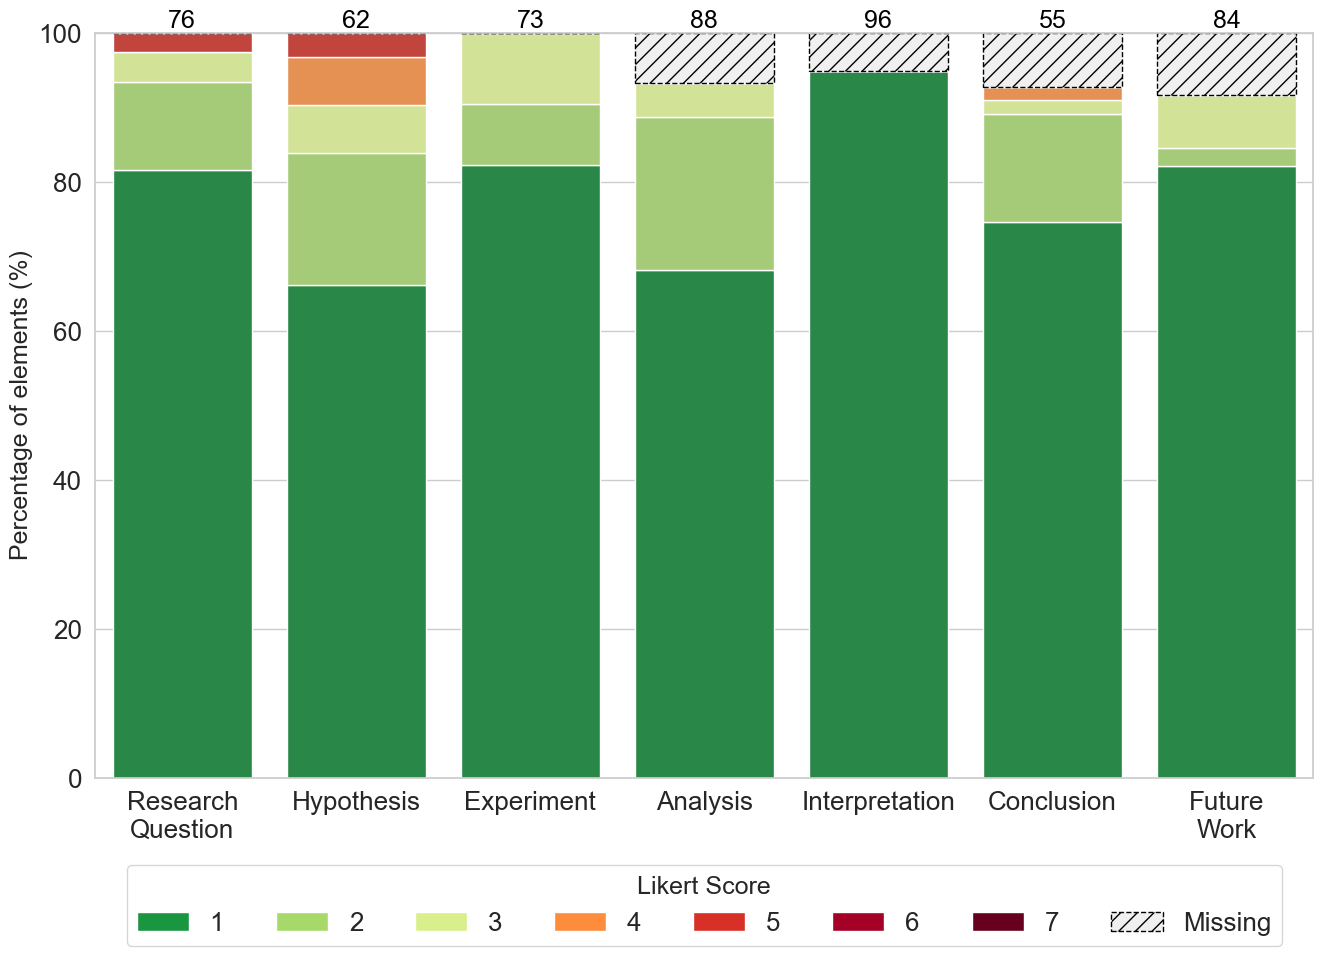

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Load the dataframe from your csv file
file_path = 'output.csv'
df = pd.read_csv(file_path)

# --- Data Transformation for 100% Stacked Bar Chart ---

# 1. Map original field names to new, shorter names
# 1. Map original field names to new, shorter names, grouping suggestions
#    into 'Future Work'.
field_mapping = {
    'Research Question Likert Score': 'Research Question',
    'Hypothesis Likert Score': 'Hypothesis',
    'Experiment Description Likert Score': 'Experiment',
    'Analysis Likert Score': 'Analysis',
    'Interpretation Likert Score': 'Interpretation',
    'Conclusion Likert Score': 'Conclusion',
    'Suggested Research Question Likert Score': 'Future Work',
    'Suggested Hypothesis Likert Score': 'Future Work'
}
df['section'] = df['section'].map(field_mapping)

# 2. Define the desired order for the fields
field_order = [
    'Research Question',
    'Hypothesis',
    'Experiment',
    'Analysis',
    'Interpretation',
    'Conclusion',
    'Future Work'
]

# Create a cross-tabulation to count occurrences of each Likert 'value' for each 'section'
counts_df = pd.crosstab(df['section'], df['value'])

# 3. Reorder the DataFrame according to the specified field_order
#    and ensure all Likert values (-1 and 1-7) are present as columns.
all_scores = [1, 2, 3, 4, 5, 6, 7, -1]
counts_df = counts_df.reindex(field_order, fill_value=0).reindex(columns=all_scores, fill_value=0)

# Calculate the percentage of each Likert score for each field
percentages_df = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

# --- Plotting ---

# Set up the plot style
sns.set_theme(style="whitegrid", font_scale=1.7)
plt.figure(figsize=(14, 10))

# Create the 100% stacked bar chart
# The `bottom` parameter is updated in each iteration to stack the bars
bottom = pd.Series([0.0] * len(percentages_df), index=percentages_df.index)

# 4. Define colors for the Likert scale values
colors = {
    -1: "#f0f0f0",
    1: "#1a9641",  # Dark Green (Good)
    2: "#a6d96a",  # Light Green
    3: "#d9ef8b",  # Yellow-Green (Slightly Positive)
    4: "#fd8d3c",  # Darker Orange (Neutral)
    5: "#d73027",  # Red (Negative)
    6: "#a50026",  # Dark Red
    7: "#67001f"   # Very Dark Red (Abysmal)
}

# --- Build color map (green → red) ---
# import numpy as np
# scores = [1,2,3,4,5,6,7]
# norm_vals = (np.array(scores) - min(scores)) / (max(scores) - min(scores))
# colors = plt.cm.RdYlGn_r(norm_vals)


for score in percentages_df.columns:
    bar_kwargs = {
        'color': colors[score],
        'label': str(score)
    }
    if score == -1:
        bar_kwargs['edgecolor'] = 'black'
        bar_kwargs['linestyle'] = '--'
        bar_kwargs['linewidth'] = 1
        bar_kwargs['hatch'] = '//'

    ax = sns.barplot(
        x=percentages_df.index,
        y=percentages_df[score],
        order=percentages_df.index,
        bottom=bottom,
        **bar_kwargs
    )
    # Update the bottom for the next stack
    bottom += percentages_df[score]

# Calculate total counts for each section
total_counts = counts_df.sum(axis=1)

# Add total counts on top of each bar
for i, section in enumerate(percentages_df.index):
    total = total_counts[section]
    ax.text(i, 100, f'{total}', ha='center', va='bottom', fontsize=18, color='black')
# --- Formatting and Labels ---

# Add titles and labels for clarity
ax.set_xlabel(None)
ax.set_ylabel('Percentage of elements (%)', fontsize=18)

# Define full set of possible labels
all_legend_labels = {
    1: "1 - Nearly Perfect",
    2: "2 - Correct",
    3: "3 - Acceptable",
    4: "4 - Partially Incorrect",
    5: "5 - Incorrect",
    6: "6 - No overlap",
    7: "7 - Hallucinatory",
    -1: "Missing"
}

# Create legend handles and labels for all possible scores (1-7)
legend_handles = []
legend_labels = []
for score in all_scores:
    patch_kwargs = {'facecolor': colors[score]}
    if score == -1:
        patch_kwargs['edgecolor'] = 'black'
        patch_kwargs['linestyle'] = '--'
        patch_kwargs['linewidth'] = 1
        patch_kwargs['hatch'] = '//'
    legend_handles.append(Patch(**patch_kwargs))
    legend_labels.append(str(score) if score != -1 else "Missing")

# Add a legend with custom handles to ensure colors are displayed correctly
xtick_labels = [label.replace(' ', '\n') if ' ' in label else label for label in percentages_df.index]
ax.set_xticklabels(xtick_labels)
ax.legend(handles=legend_handles, labels=legend_labels, title='Likert Score', title_fontsize=18, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(all_scores))

# Ensure the layout is tight
plt.tight_layout()

# Display the plot
plt.savefig(f"plots/likert_scale_bars.pdf", dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


In [8]:
# Display the percentages dataframe
percentages_df

value,1,2,3,4,5,6,7,-1
section,,,,,,,,
Research Question,81.578947,11.842105,3.947368,0.000000,2.631579,0.0,0.0,0.000000
Hypothesis,66.129032,17.741935,6.451613,6.451613,3.225806,0.0,0.0,0.000000
Experiment,82.191781,8.219178,9.589041,0.000000,0.000000,0.0,0.0,0.000000
Analysis,68.181818,20.454545,4.545455,0.000000,0.000000,0.0,0.0,6.818182
Interpretation,94.791667,0.000000,0.000000,0.000000,0.000000,0.0,0.0,5.208333
Conclusion,74.545455,14.545455,1.818182,1.818182,0.000000,0.0,0.0,7.272727
Future Work,82.142857,2.380952,7.142857,0.000000,0.000000,0.0,0.0,8.333333


In [9]:
df[df["value"] == -1]["Paper"].to_list()

['Data Efficient Pre-training for Language Models An Empirical Study of Compute Efficiency and Linguistic Competence',
 'Data Efficient Pre-training for Language Models An Empirical Study of Compute Efficiency and Linguistic Competence',
 'Rethinking Evaluation Paradigms in IBP-based Certified Training',
 'Rethinking Evaluation Paradigms in IBP-based Certified Training',
 'Towards Consistent and Efficient Decision-based Attacks',
 'Towards Consistent and Efficient Decision-based Attacks',
 'Robustness Distributions in Neural Network Verification',
 'Weighted Initialisation of Evolutionary Instrument and Pitch Detection in Polyphonic Music',
 'Weighted Initialisation of Evolutionary Instrument and Pitch Detection in Polyphonic Music',
 'HyperSHAP: Shapley Values and Interactions for Explaining Hyperparameter Optimization',
 'Hyperparameters in Reinforcement Learning and How To Tune Them',
 'Hyperparameters in Reinforcement Learning and How To Tune Them',
 'Hyperparameters in Reinforceme

In [10]:
df[(df["section"] == "Conclusion") & (df["value"] == -1)]

,Paper,section,field,value
514,Rethinking Evaluation Paradigms in IBP-based C...,Conclusion,conclusion_3,-1
525,Hyperparameters in Reinforcement Learning and ...,Conclusion,conclusion_2,-1
526,Hyperparameters in Reinforcement Learning and ...,Conclusion,conclusion_3,-1
534,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusion,conclusion_3,-1


In [15]:
# Analysis on explicit statements and their likert scales
explicit_rqs = {'Paper': {158: 'Automatic Adjusting Global Similarity Measures in Learning CBR Systems',
  161: 'Automatic Adjusting Global Similarity Measures in Learning CBR Systems',
  164: 'Automatic Adjusting Global Similarity Measures in Learning CBR Systems',
  484: 'Instance selection for configuration performance comparison',
  487: 'Instance selection for configuration performance comparison',
  535: 'Leveraging AutoML for Sustainable Deep Learning: A Multi- Objective HPO Approach on Deep Shift Neural Networks',
  538: 'Leveraging AutoML for Sustainable Deep Learning: A Multi- Objective HPO Approach on Deep Shift Neural Networks',
  648: 'Robustness Distributions in Neural Network Verification',
  651: 'Robustness Distributions in Neural Network Verification',
  654: 'Robustness Distributions in Neural Network Verification',
  657: 'Robustness Distributions in Neural Network Verification',
  777: 'Regularized Feature Selection Landscapes An Empirical Study of Multimodality',
  780: 'Regularized Feature Selection Landscapes An Empirical Study of Multimodality',
  1156: 'Hyperparameter Optimization via Interacting with Probabilistic Circuits',
  1159: 'Hyperparameter Optimization via Interacting with Probabilistic Circuits',
  1162: 'Hyperparameter Optimization via Interacting with Probabilistic Circuits',
  1245: 'Hyperparameters in Reinforcement Learning and How To Tune Them',
  1248: 'Hyperparameters in Reinforcement Learning and How To Tune Them',
  1357: 'Trajectory-based algorithm selection with warm-starting',
  1661: 'Time Series Representations Classroom (TSRC) A Teacher-Student-based Framework for Interpretability-enhanced Unsupervised Time Series Representation Learning',
  1664: 'Time Series Representations Classroom (TSRC) A Teacher-Student-based Framework for Interpretability-enhanced Unsupervised Time Series Representation Learning',
  1667: 'Time Series Representations Classroom (TSRC) A Teacher-Student-based Framework for Interpretability-enhanced Unsupervised Time Series Representation Learning',
  2002: 'Empirical Analysis of Upper Bounds for Robustness Distributions using Adversarial Attacks',
  2005: 'Empirical Analysis of Upper Bounds for Robustness Distributions using Adversarial Attacks',
  2008: 'Empirical Analysis of Upper Bounds for Robustness Distributions using Adversarial Attacks',
  2161: 'AutoMergeNet- AutoML-Based M-Source Satellite Data Fusion Evaluated With Atmospheric Case Studies',
  2164: 'AutoMergeNet- AutoML-Based M-Source Satellite Data Fusion Evaluated With Atmospheric Case Studies',
  2167: 'AutoMergeNet- AutoML-Based M-Source Satellite Data Fusion Evaluated With Atmospheric Case Studies'},
 'Item': {158: 'research_question_1',
  161: 'research_question_2',
  164: 'research_question_3',
  484: 'research_question_1',
  487: 'research_question_2',
  535: 'research_question_2',
  538: 'research_question_3',
  648: 'research_question_2',
  651: 'research_question_3',
  654: 'research_question_4',
  657: 'research_question_5',
  777: 'research_question_1',
  780: 'research_question_2',
  1156: 'research_question_1',
  1159: 'research_question_2',
  1162: 'research_question_3',
  1245: 'research_question_3',
  1248: 'research_question_4',
  1357: 'research_question_1',
  1661: 'research_question_1',
  1664: 'research_question_2',
  1667: 'research_question_3',
  2002: 'research_question_2',
  2005: 'research_question_3',
  2008: 'research_question_4',
  2161: 'research_question_1',
  2164: 'research_question_2',
  2167: 'research_question_3'}}

explicit_hypotheses = {'Paper': {9: 'Edge-Based Graph Component Pooling',
  361: 'An Evaluation of Neural Network Architectures for Predicting Hydro Unit Commitment Decisions',
  410: 'Applying and benchmarking a stochastic programming-based bidding strategy for day-ahead hydropower scheduling',
  548: 'Leveraging AutoML for Sustainable Deep Learning: A Multi- Objective HPO Approach on Deep Shift Neural Networks',
  663: 'Robustness Distributions in Neural Network Verification',
  958: 'HyperSHAP: Shapley Values and Interactions for Explaining Hyperparameter Optimization',
  1936: 'Combining Automated Optimisation of Hyperparameters and Reward Shape',
  1940: 'Combining Automated Optimisation of Hyperparameters and Reward Shape',
  1944: 'Combining Automated Optimisation of Hyperparameters and Reward Shape'},
 'Item': {9: 'hypothesis_1',
  361: 'hypothesis_1',
  410: 'hypothesis_1',
  548: 'hypothesis_2',
  663: 'hypothesis_1',
  958: 'hypothesis_1',
  1936: 'hypothesis_1',
  1940: 'hypothesis_2',
  1944: 'hypothesis_3'}}

In [12]:
df

,Paper,section,field,value
0,Robustness Distributions in Neural Network Ver...,Research Question,research_question_1,1
1,Robustness Distributions in Neural Network Ver...,Research Question,research_question_2,1
2,Robustness Distributions in Neural Network Ver...,Research Question,research_question_3,1
3,Robustness Distributions in Neural Network Ver...,Research Question,research_question_4,1
4,Robustness Distributions in Neural Network Ver...,Research Question,research_question_5,1
...,...,...,...,...
530,Dynamic Algorithm Termination for Branch-and-B...,Analysis,analysis_6,-1
531,Dynamic Algorithm Termination for Branch-and-B...,Interpretation,interpretation_4,-1
532,AutoMergeNet- AutoML-Based M-Source Satellite ...,Analysis,analysis_3,-1
533,AutoMergeNet- AutoML-Based M-Source Satellite ...,Interpretation,interpretation_3,-1


In [ ]:
explicit_rq_likert = []

for id, paper in explicit_rqs["Paper"].items():
    item_key = explicit_rqs["Item"][id]
    explicit_rq_likert.append(df[(df["Paper"] == paper) & (df["section"] == "Research Question") & (df["field"] == item_key)]["value"].values[0])
    if explicit_rq_likert[-1] > 1:
        print(paper, item_key, explicit_rq_likert[-1])

import numpy
np.mean(explicit_rq_likert)

Automatic Adjusting Global Similarity Measures in Learning CBR Systems research_question_1 2
Leveraging AutoML for Sustainable Deep Learning: A Multi- Objective HPO Approach on Deep Shift Neural Networks research_question_2 2


np.float64(1.0714285714285714)

In [19]:
explicit_h_likert = []

for id, paper in explicit_hypotheses["Paper"].items():
    item_key = explicit_hypotheses["Item"][id]
    explicit_h_likert.append(df[(df["Paper"] == paper) & (df["section"] == "Hypothesis") & (df["field"] == item_key)]["value"].values[0])
    if explicit_h_likert[-1] > 1:
        print(paper, item_key, explicit_h_likert[-1])

import numpy
np.mean(explicit_h_likert)

Edge-Based Graph Component Pooling hypothesis_1 2
Combining Automated Optimisation of Hyperparameters and Reward Shape hypothesis_2 2


np.float64(1.2222222222222223)